In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("with_race/ihdp_with_race_1.csv")
df.describe()

,treat,y_factual,y_cfactual,mu0,mu1,bw,b.head,preterm,birth.o,nnhealth,...,ark,ein,har,mia,pen,tex,was,momwhite,momblack,momhisp
count,747.000000,747.000000,747.000000,747.000000,747.000000,7.470000e+02,7.470000e+02,7.470000e+02,7.470000e+02,7.470000e+02,...,747.000000,747.000000,747.000000,747.000000,747.000000,747.000000,747.000000,747.000000,747.000000,747.000000
mean,0.186078,3.159538,5.696107,2.432513,6.448580,2.853585e-17,-9.511951e-18,-2.853585e-17,-5.849850e-16,2.853585e-17,...,0.135207,0.135207,0.156627,0.081660,0.073628,0.128514,0.157965,0.485944,0.423025,0.091031
std,0.389430,2.179956,1.980121,1.281515,0.454766,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.342174,0.342174,0.363692,0.274029,0.261339,0.334886,0.364953,0.500137,0.494370,0.287846
min,0.000000,-1.543902,-1.037628,0.924453,5.591647,-2.731287e+00,-3.800823e+00,-1.850350e+00,-8.796060e-01,-5.130428e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.626779,5.053598,1.518409,6.087863,-6.669461e-01,-6.027100e-01,-7.332610e-01,-8.796060e-01,-5.666720e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2.577294,6.209686,2.114661,6.419095,1.652752e-01,1.968181e-01,-3.608980e-01,1.617025e-01,1.210172e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,4.494637,6.948922,2.989305,6.765241,8.137593e-01,5.965822e-01,7.561910e-01,1.617025e-01,6.836721e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,11.268228,10.171004,9.821792,7.954804,1.505476e+00,2.595403e+00,2.990369e+00,2.244320e+00,2.371637e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
sum(df["treat"] == 1), sum(df["treat"] == 0)

(139, 608)

In [4]:
df["y0"] = np.where(df["treat"] == 1, df["y_cfactual"], df["y_factual"])
df["y1"] = np.where(df["treat"] == 1, df["y_factual"], df["y_cfactual"])

df[["y0", "y1"]].describe()

,y0,y1
count,747.000000,747.000000
mean,2.412991,6.442653
std,1.596864,1.102065
min,-1.543902,3.210085
25%,1.448038,5.734262
50%,2.250801,6.452305
75%,3.113372,7.176373
max,11.268228,10.171004


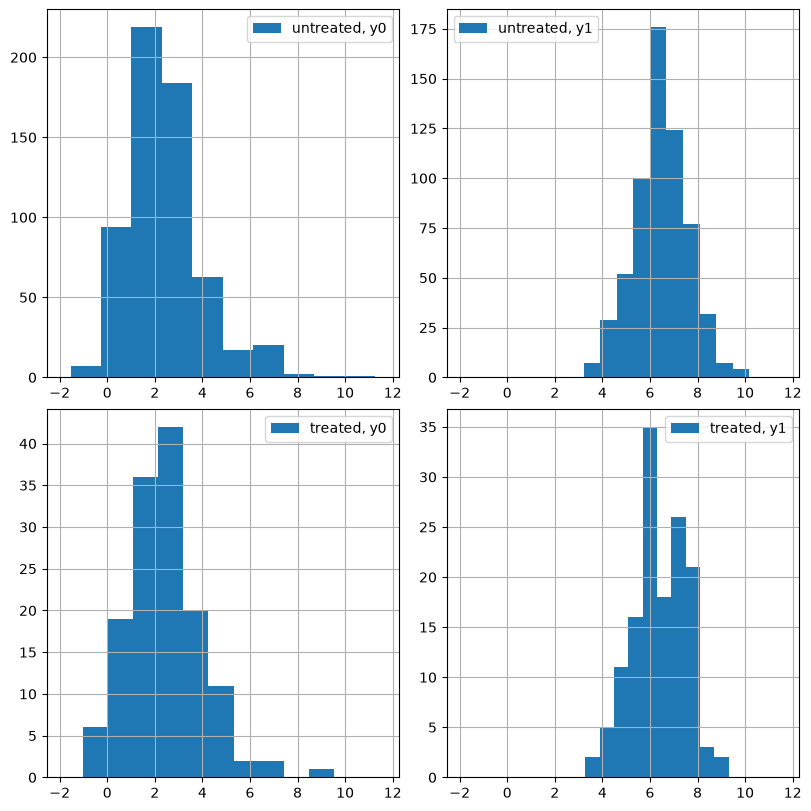

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)

axs[0, 0].hist(df[df["treat"] == 0]["y0"], label="untreated, y0")
axs[0, 1].hist(df[df["treat"] == 0]["y1"], label="untreated, y1")
axs[1, 0].hist(df[df["treat"] == 1]["y0"], label="treated, y0")
axs[1, 1].hist(df[df["treat"] == 1]["y1"], label="treated, y1")

x_min = min(df["y0"].min(), df["y1"].min())
x_max = max(df["y0"].max(), df["y1"].max())
for ax in axs.flatten():
    ax.set_xlim(x_min - 1, x_max + 1)
    ax.grid()
    ax.legend()

plt.show()